In [26]:
# Carregando as bibliotecas

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [5]:
# Carregando datasets
df_initial = pd.read_csv(
    "../datasets/processed/df_initial_v1.csv"
)

df_final_v1 = pd.read_csv(
    "../datasets/processed/df_united_v1.csv"
)

In [6]:
print("Initial:", df_initial.shape)
print("Final V1:", df_final_v1.shape)

Initial: (10000, 23)
Final V1: (115934, 23)


In [8]:
df_final_train, df_final_holdout = train_test_split(
    df_final_v1,
    test_size=0.20,
    stratify=df_final_v1["label"],
    random_state=42
)

In [9]:
print("df_final_train :", len(df_final_train))
print("df_final_holdout :", len(df_final_holdout))

df_final_train : 92747
df_final_holdout : 23187


In [10]:
df_3a = pd.concat(
    [df_initial, df_final_train],
    ignore_index=True
)

In [11]:
print(df_3a.shape)

df_3a["label"].value_counts()

(102747, 23)


label
1    51374
0    51373
Name: count, dtype: int64

In [12]:
X_train = df_3a.drop(
    columns=["label"],
    errors="ignore"
)

y_train = df_3a["label"]

In [13]:
X_test = df_final_holdout.drop(
    columns=["label", "source"],
    errors="ignore"
)

y_test = df_final_holdout["label"]

In [14]:
print(X_train.shape)
print(X_test.shape)

print(
    list(X_train.columns)
    ==
    list(X_test.columns)
)

(102747, 22)
(23187, 22)
True


In [15]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [16]:
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(
    X_train,
    y_train
)

dt_pred = dt.predict(X_test)

In [17]:
lr = LogisticRegression(
    max_iter=1000
)

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

c:\Users\u513127\Downloads\phishing-project-kaggle-main\phishing-project-kaggle-main\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [18]:
def evaluate_model(name, y_true, y_pred):

    print(f"\n===== {name} =====")

    print(
        "Accuracy:",
        accuracy_score(y_true, y_pred)
    )

    print(
        "Precision:",
        precision_score(y_true, y_pred)
    )

    print(
        "Recall:",
        recall_score(y_true, y_pred)
    )

    print(
        "F1:",
        f1_score(y_true, y_pred)
    )

In [19]:
evaluate_model(
    "Random Forest",
    y_test,
    rf_pred
)

evaluate_model(
    "Decision Tree",
    y_test,
    dt_pred
)

evaluate_model(
    "Logistic Regression",
    y_test,
    lr_pred
)


===== Random Forest =====
Accuracy: 0.9966360460602924
Precision: 0.9992196306251626
Recall: 0.9940481324937462
F1: 0.9966271728790106

===== Decision Tree =====
Accuracy: 0.9890024582740329
Precision: 0.9982422218316048
Recall: 0.9797291468989908
F1: 0.9888990466240042

===== Logistic Regression =====
Accuracy: 0.9883555440548584
Precision: 0.9875139929389477
Recall: 0.9892176313292504
F1: 0.9883650779970697


In [21]:
cm = confusion_matrix(
    y_test,
    rf_pred
)

cm

array([[11585,     9],
       [   69, 11524]])

In [23]:
print(
    classification_report(
        y_test,
        rf_pred
    )
)

              precision    recall  f1-score   support

           0       0.99      1.00      1.00     11594
           1       1.00      0.99      1.00     11593

    accuracy                           1.00     23187
   macro avg       1.00      1.00      1.00     23187
weighted avg       1.00      1.00      1.00     23187



In [28]:
results = pd.DataFrame([
    {
        "Model": "Random Forest",
        "Accuracy": accuracy_score(y_test, rf_pred),
        "Precision": precision_score(y_test, rf_pred),
        "Recall": recall_score(y_test, rf_pred),
        "F1": f1_score(y_test, rf_pred)
    },
    {
        "Model": "Decision Tree",
        "Accuracy": accuracy_score(y_test, dt_pred),
        "Precision": precision_score(y_test, dt_pred),
        "Recall": recall_score(y_test, dt_pred),
        "F1": f1_score(y_test, dt_pred)
    },
    {
        "Model": "Logistic Regression",
        "Accuracy": accuracy_score(y_test, lr_pred),
        "Precision": precision_score(y_test, lr_pred),
        "Recall": recall_score(y_test, lr_pred),
        "F1": f1_score(y_test, lr_pred)
    }
])

results

,Model,Accuracy,Precision,Recall,F1
0,Random Forest,0.996636,0.999220,0.994048,0.996627
1,Decision Tree,0.989002,0.998242,0.979729,0.988899
2,Logistic Regression,0.988356,0.987514,0.989218,0.988365


A degradação observada na validação externa não estava relacionada exclusivamente à limitação das features utilizadas, mas principalmente à defasagem temporal do conjunto de treinamento. A incorporação de amostras recentes permitiu restaurar a capacidade de generalização do modelo, elevando a acurácia de 59,3% para 99,66% em um conjunto holdout de URLs modernas.

In [24]:
feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

feature_importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
18,HostnameLength,0.224837
17,DomainInPaths,0.184263
16,DomainInSubdomains,0.153981
1,SubdomainLevel,0.117713
19,PathLength,0.077123
4,NumDash,0.053317
2,PathLevel,0.036255
3,UrlLength,0.032315
5,NumDashInHostname,0.025672
0,NumDots,0.024178


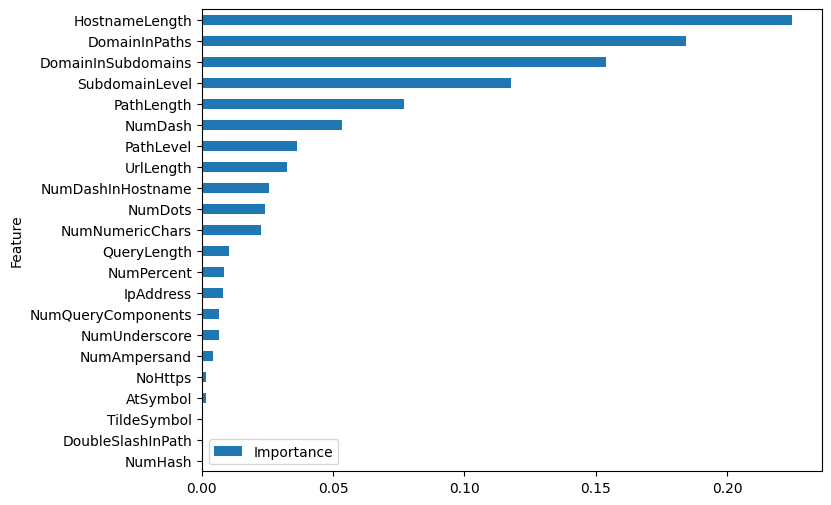

In [27]:
feature_importance.sort_values(
    by="Importance",
    ascending=True
).plot(
    x="Feature",
    y="Importance",
    kind="barh",
    figsize=(8,6)
)

plt.show()